<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C8_Libro_Ejercicios_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio para la Sección 1

**Objetivo**: Diferenciar cuándo aplicar clasificación o regresión en un dataset real.

**Instrucciones**:

1. Carga el dataset del Titanic (sns.load_dataset("titanic")).
2. Define si la predicción de supervivencia es clasificación o regresión.
3. Aplica un modelo de Regresión Logística para predecir la supervivencia.
4. Aplica una Regresión Lineal para predecir la tarifa del boleto según la edad.
5. Explica qué modelo fue más apropiado en cada caso.


In [ ]:
from IPython.core.interactiveshell import dis
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split

# 1. Carga el dataset del Titanic (sns.load_dataset("titanic")).
df = sns.load_dataset("titanic").dropna()
display(df.head(4))

# Preprocesamiento
# Categorizar variable sex
df["sex"] = df["sex"].map({"male": 1, "female": 0})

# Categorizar variable alone
df["alone"] = df["alone"].map({True: 1, False: 0})

display(df.head(4))
# Escalar los datos...


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,0
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,0
6,0,1,1,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,1
10,1,3,0,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,0


Este código prepara datos y entrena dos modelos de Machine Learning diferentes usando el dataset Titanic:

Un modelo de clasificación → predecir si una persona sobrevivió o no.

Un modelo de regresión → predecir el valor del pasaje (fare) según la edad.

 La prediccioón de survived es del tipo Clasificación, predice una categoría: si sobrevivió (1) o no (0).
Precisión Logística: 0.70


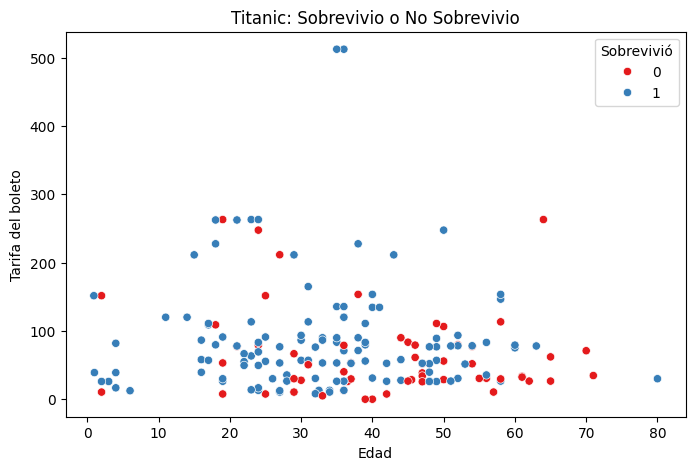

In [ ]:
# 2. Define si la predicción de supervivencia es clasificación o regresión.
print(' La prediccioón de survived es del tipo Clasificación, predice una categoría: si sobrevivió (1) o no (0).')

# 3. Aplica un modelo de Regresión Logística para predecir la supervivencia.
X_class = df[["pclass", "sex", "age", "fare", "alone"]]
y_class = df["survived"]

# Entrenamiento y prueba - Clasificación
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Modelo de Clasificación
clf = LogisticRegression(max_iter=1000).fit(X_tr_c, y_tr_c)

print(f"Precisión Logística: {clf.score(X_te_c, y_te_c):.2f}")

# Graficamos Sobrevivio o No Sobrevivio
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df, x="age", y="fare", hue="survived", palette="Set1"
)

plt.title("Titanic: Sobrevivio o No Sobrevivio")
plt.xlabel("Edad")
plt.ylabel("Tarifa del boleto")
plt.legend(title="Sobrevivió", loc="upper right")
plt.show()

R² Lineal:           0.04


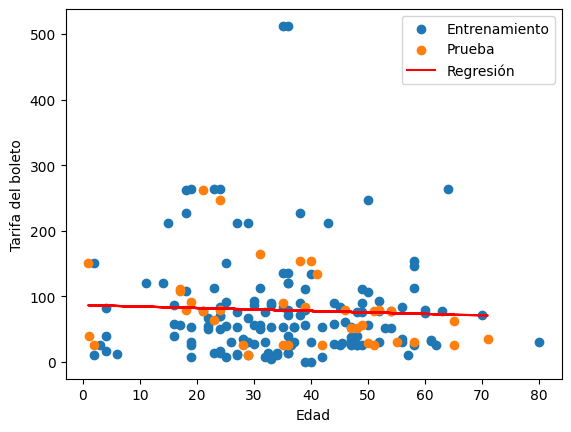

In [ ]:
#4. Aplica una Regresión Lineal para predecir la tarifa del boleto según la edad.
# Regresión: predice un valor numérico continuo (tarifa del boleto)
# “Según la edad, ¿cuál podría ser la tarifa del boleto?”
X_reg   = df[["age"]]
y_reg   = df["fare"]

# Entrenamiento y prueba - Regresión
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg,   y_reg,   test_size=0.2, random_state=42)

# Modelo de Regresión
reg = LinearRegression().fit(X_tr_r, y_tr_r)

print(f"R² Lineal:           {reg.score(X_te_r, y_te_r):.2f}")

# Graficamos
plt.scatter(X_tr_r, y_tr_r, label="Entrenamiento")
plt.scatter(X_te_r, y_te_r, label="Prueba")
plt.plot(X_te_r, reg.predict(X_te_r), color="red", label="Regresión")
plt.xlabel("Edad")
plt.ylabel("Tarifa del boleto")
plt.legend()
plt.show()

**Preguntas de Reflexión**

* 1. ¿Por qué es más adecuado usar Regresión Logística para predecir la supervivencia?*

Es mas adecuado ya que es un algoritmo de Clasificación para variables del tipo categórica, en este caso predice 'si sobrevivió (1) o no (0)'. Estima la probabilidad de una categoría (0 o 1).

*2. ¿Por qué la Regresión Lineal es más apropiada para predecir la tarifa del boleto?*

Es más adecuado ya que se utiliza para predecir variables del tipo continuas, en este caso la variable es la tarifa del boleto.

*3. ¿Qué características adicionales podríamos incluir para mejorar los modelos?*

Para mejorar ambos modelos (predicción de supervivencia y predicción de tarifa), podrías considerar incluir las siguientes características adicionales:

Para la Predicción de Supervivencia (Regresión Logística):

* pclass (Clase de Pasajero): Este es un predictor fuerte de supervivencia, ya que los pasajeros de clases superiores a menudo tenían mejor acceso a los botes salvavidas.
* sex (Género): Como se ha visto en datos históricos, las mujeres y los niños solían tener prioridad para sobrevivir.
* sibsp (Número de Hermanos/Cónyuges a Bordo): Esto podría indicar el tamaño de la familia, lo que podría influir en las posibilidades de supervivencia.
* parch (Número de Padres/Hijos a Bordo): Similar a sibsp, indica el tamaño de la familia.
* embark_town (Puerto de Embarque): Diferentes puertos de embarque podrían haber tenido pasajeros de distintos orígenes socioeconómicos.
* deck (Número de cubierta): Podría correlacionarse con la clase de pasajero y la proximidad a los botes salvavidas.

Para la Predicción de Tarifa (Regresión Lineal):

* pclass (Clase de Pasajero): Esto está altamente correlacionado con la tarifa, ya que las clases más altas pagaban más.
* sex (Género): Aunque menos directo, podría haber habido ligeras diferencias en la tarifa para hombres y mujeres en ciertas clases o camarotes.
* embarked (Puerto de Embarque): Las tarifas podrían variar ligeramente según el puerto de salida.
* deck (Número de cubierta): Directamente relacionado con el tipo de camarote y, por lo tanto, con la tarifa.
* sibsp y parch (Tamaño de la familia): Las familias más grandes podrían haber reservado camarotes más grandes o haber recibido descuentos/paquetes familiares, lo que afectaría la tarifa general por persona o grupo.

Al añadir estas características, recuerda manejar las variables categóricas (como sex, pclass, embark_town, deck) de forma adecuada utilizando técnicas como la codificación one-hot para que los modelos puedan interpretarlas correctamente.


# Ejercicio para la Sección 2

**Objetivo**: Aplicar Regresión Logística en un problema real.

**Instrucciones**:

1. Carga el dataset del Titanic.
2. Selecciona age, fare y sex como variables predictoras.
3. Transforma sex en variable numérica (0 = femenino, 1 = masculino).
4. Aplica Regresión Logística para predecir la supervivencia.
5. Evalúa el modelo con una matriz de confusión y precisión.


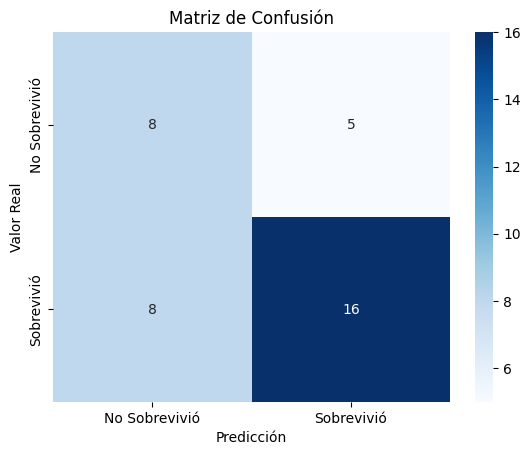

Precisión: 0.65
Matriz de Confusión:
 [[ 8  5]
 [ 8 16]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.50      0.62      0.55        13
           1       0.76      0.67      0.71        24

    accuracy                           0.65        37
   macro avg       0.63      0.64      0.63        37
weighted avg       0.67      0.65      0.66        37



In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Carga el dataset del Titanic y elimina filas con valores faltantes.
df = sns.load_dataset("titanic").dropna()

# 2. Selecciona age, fare y sex como variables predictoras.
# 3. Transforma sex en variable numérica (0 = femenino, 1 = masculino).
df["sex"] = df["sex"].map({"male": 1, "female": 0})
X = df[["age", "fare", "sex"]]
y = df["survived"]

# 4. Aplica Regresión Logística para predecir la supervivencia.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo de Clasificación - Regresión Logística aprende patrones para clasificar: sobrevivió / no sobrevivió
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Realizar predicciones, intenta adivinar si cada pasajero sobrevivió.
y_pred = model.predict(X_test)

# 5. Evalúa el modelo con una matriz de confusión y precisión.
cm = confusion_matrix(y_test, y_pred)
#print(cm)

# Graficamso
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Sobrevivió', 'Sobrevivió'], yticklabels=['No Sobrevivió','Sobrevivió'])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()

print(f"Precisión: {accuracy_score(y_test, y_pred):.2f}")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))

**Preguntas de Reflexión**

*1. ¿Cómo afecta la variable "sexo" a la predicción de supervivencia?*

Considerando que se trata del dataset Titanic, la variable 'sex' tiene mucho peso, ya que se priorizaba evacuar primero a las mujeres y los niños. El modelo aprende que muchas mujeres sobrevivieron y la mayoría de los hombres no sobrevivieron, las predicciones son en base a esas premisas. Pero pueden haber casos de hombres que no validan esa premisas, por ello usa Regrwsión Logística, ya que asigna peso a cada variable.

*2. ¿Por qué es importante balancear precisión y recall?*

Precisión, mide de todos los casos que el modelo predijo como positivos, cuantos eran realmente  positivos. Recall, mide de todos los positivos reales, cuantos logro detectar el modelo. Es importante balancear ambas métricas porque el modelo puede tener errores importantes, usando una sola de ellas. Para ello, podemos observar el valor de F1-score que combina ambas métricas. De todas formas, el uso de alguna de ellas, depende del problema a analizar. Por ejemplo, en medicina suele ser mas importante Recall y si se analiza correo Spam importa más la precisión. En nuestro caso de Titanic, es importante tener  un equilibrio en el uso de las métricas individuales. Según el mayor valor de precisión (0.76), el modelo funcionó mejor detectando sobrevivientes.

*3. ¿Cómo podríamos mejorar el modelo agregando más variables?*

Podríamos categorizar las edades en niños, adultos, mayores, se sabe que los niños tuvieron prioridad en el rescate sumado a las mujeres. También la clase en la que viajaba el pasajero, se conoce que los de primera clase tuvieron mas sobrevivientes que los de tercera clase que tuvieron menos posibilidades.



# Ejercicio para la Sección 3

**Instrucciones**:

1. Carga un dataset de precios de viviendas.
2. Selecciona variables como superficie, habitaciones y baños como predictoras.
3. Aplica Regresión Múltiple para predecir el precio.
4. Evalúa el modelo con R², MSE y MAE.
5. Analiza si hay multicolinealidad con VIF y corrige si es necesario.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 1. Carga un dataset de precios de viviendas.
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
#display(df.head())

# 2. Selecciona variables como superficie, habitaciones y baños como predictoras.
# Utilizamos las columnas disponibles relevantes para la predicción.
X = df[["total_rooms", "total_bedrooms", "households"]]
y = df["median_house_value"]

# Escalar, ya que hay diferntes coeficientes
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# 3. Aplica Regresión Múltiple para predecir el precio.
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Evalúa el modelo con R², MSE y MAE.
print(f"R²: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# 5. Analiza si hay multicolinealidad con VIF y corrige si es necesario.
# Multicolinealidad en Regresión Múltiple
# Factor de Inflación de Varianza (VIF) > 10 indica alta multicolinealidad
print('\n---- Analiza si hay multicolinealidad con VIF ----\n')
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_sc, i) for i in range(X_sc.shape[1])]
print(vif_data)

# Corregimos
print('\n---- Corregimos ----\n')
X2 = df[["total_rooms", "households"]]
X2_sc = scaler.fit_transform(X2)
vif_data2 = pd.DataFrame()
vif_data2["Variable"] = X2.columns
vif_data2["VIF"] = [variance_inflation_factor(X2_sc, i) for i in range(X2_sc.shape[1])]
print(vif_data2)

R²: 0.07
MSE: 12839991016.08
MAE: 88742.91

---- Analiza si hay multicolinealidad con VIF ----

         Variable        VIF
0     total_rooms   7.340399
1  total_bedrooms  30.181614
2      households  26.814465

---- Corregimos ----

      Variable       VIF
0  total_rooms  6.434784
1   households  6.434784


**Preguntas de Reflexión**

*1. ¿Qué variable tiene mayor impacto en el precio de la vivienda?*

La variable con mayor impacto en el modelo es total_bedrooms, ya que tenía el valor de VIF más alto antes de corregir y mostraba una fuerte correlación con otras variables. Sin embargo, debido a la multicolinealidad detectada, su influencia no podía interpretarse correctamente de forma individual.

Después de corregir la multicolinealidad y eliminar variables altamente correlacionadas, las variables que permanecieron fueron total_rooms y households, siendo total_rooms la que probablemente tenga mayor aporte para explicar el precio de la vivienda, ya que representa el tamaño general de la propiedad.

*2. ¿Cómo afecta la multicolinealidad a la interpretación del modelo?*

La multicolinealidad ocurre cuando dos o más variables predictoras están altamente relacionadas entre sí. En este caso, total_bedrooms y households tenían valores de VIF muy elevados (superiores a 10), indicando una fuerte correlación entre las variables.

Esto afecta al modelo porque:

* Hace que los coeficientes sean inestables.
* Dificulta identificar el verdadero impacto de cada variable.
* Puede generar interpretaciones incorrectas sobre la importancia de las variables.
* Reduce la confiabilidad estadística del modelo.

Por ese motivo, se corrigió eliminando variables redundantes hasta obtener valores de VIF cercanos a 6, lo que mejora la estabilidad e interpretación del modelo.

*3. ¿Cómo podríamos mejorar el modelo?*

El modelo podría mejorarse de varias maneras:

* Incorporando más variables relevantes del dataset, como: median_income, housing_median_age, population, ubicación geográfica (latitude y longitude).
* Realizando un escalado o normalización de datos para mejorar el rendimiento del algoritmo.
* Eliminando outliers que puedan afectar las predicciones.
* Probando modelos más avanzados, como:
    * Árboles de decisión
    * Random Forest
    * Gradient Boosting
* Aplicando ingeniería de características para crear nuevas variables más representativas.

Además, el valor de R² = 0.07 indica que el modelo actualmente explica solo el 7% de la variabilidad del precio, por lo que todavía tiene poca capacidad predictiva y requiere mejoras para obtener resultados más precisos.


# Sección 4: Ejercicio Integrador y Publicación en el Foro Obligatorio

Resolución en otro Notebook